<div align='center'>

# **Práctica 2 - Parte II: Modelado de Temas con BERTopic**

**Máster Universitario en Inteligencia Artificial**  
**Asignatura:** Minería de Textos y Modelos de Lenguaje

<br/>
Autores:
- Cristian Rubio Barato - <a href='mailto:Cristian.Rubio@alu.uclm.es'>Cristian.Rubio@alu.uclm.es</a>  
- José Lara Navarro - <a href='mailto:Jose.Lara3@alu.uclm.es'>Jose.Lara3@alu.uclm.es</a>

</div>

<a id='indice'></a>

**Índice**

- [1. Preparación del corpus](#sec1)
- [2. Generación de los embeddings de documentos](#sec2)
- [3. Aplicación del pipeline de BERTopic](#sec3)
- [4. Interpretación de los temas](#sec4)
- [5. Visualización del espacio temático](#sec5)
- [6. Análisis del impacto de los hiperparámetros](#sec6)
- [7. Comparación con modelos clásicos](#sec7)
- [8. Evaluación cuantitativa de los temas (Opcional)](#sec8)
- [9. Declaración de uso responsable de Inteligencia Artificial](#sec9)

In [1]:
# ── Instalación de dependencias (ejecutar una vez) ──
# Tras ejecutar esta celda, reinicia el runtime (Runtime > Restart session)
# antes de continuar con el resto del cuaderno.
!pip install -q sentence-transformers bertopic pandas --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.8/570.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 76.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.


### Persistencia de modelos

Todos los embeddings y modelos entrenados se guardan automáticamente en la carpeta `modelos_bertopic/`. Si la sesión de Colab se interrumpe, basta con volver a ejecutar las celdas: detectarán los ficheros existentes y cargarán desde disco en lugar de recalcular.


<a id='sec1'></a>
## 1. Preparación del corpus

Para esta segunda parte de la práctica necesitamos dos versiones del corpus:

- El **texto original** (columna `cuerpo` del CSV), que será la entrada del modelo de embeddings. Los modelos de lenguaje como SBERT fueron entrenados sobre texto natural con su estructura gramatical completa, por lo que alimentarlos con texto lematizado (sin stopwords, sin flexión, sin conectores) puede degradar la calidad de las representaciones vectoriales. Este punto se verificará experimentalmente en la sección 2.
- El **corpus lematizado** generado en la Parte I (`corpus_lemas.pkl`), que utilizaremos para la etapa de representación c-TF-IDF de BERTopic. Al extraer las palabras clave de cada tema, sí interesa trabajar con lemas para evitar que formas flexionadas del mismo término se cuenten como palabras distintas.

A partir de ambos, eliminamos valores nulos y seleccionamos una muestra aleatoria de 5000 documentos. El guion de la práctica establece un rango de 1000 a 10.000. Elegimos 5000 como punto medio: con 1000 documentos la estructura temática puede quedar incompleta (temas minoritarios con pocos representantes), mientras que con 10.000 los tiempos de UMAP crecen cuadráticamente con el número de documentos y pueden superar los 10 minutos en la CPU de Colab. Con 5000 el paso de UMAP se completa en menos de un minuto y la muestra representa el 8.5% del corpus total (~58.000), proporción suficiente para preservar la distribución temática.

In [2]:
import pandas as pd
import numpy as np
import pickle
import os

SAVE_DIR = "modelos_bertopic"
os.makedirs(SAVE_DIR, exist_ok=True)

# Carga del corpus original
df = pd.read_csv("data_larazon_publico_v2.csv")
corpus_original = df["cuerpo"].copy()
print(f"Documentos en el CSV: {len(corpus_original)}")

# Carga del corpus lematizado de la Parte I
PICKLE_PATH = "corpus_lemas.pkl"
with open(PICKLE_PATH, "rb") as f:
    lemas = pickle.load(f)
print(f"Documentos en el pickle lematizado: {len(lemas)}")

# Limpieza: eliminar nulos y documentos vacíos en ambos corpus
mascara = corpus_original.notna() & lemas.notna()
mascara &= corpus_original.str.strip().astype(bool) & lemas.str.strip().astype(bool)
corpus_original = corpus_original[mascara].reset_index(drop=True)
lemas = lemas[mascara].reset_index(drop=True)
print(f"Documentos tras eliminar nulos/vacíos: {len(corpus_original)}")

# Muestreo
SAMPLE_SIZE = 5000
np.random.seed(42)
indices = np.random.choice(len(corpus_original), size=SAMPLE_SIZE, replace=False)
indices = sorted(indices)

docs_original = corpus_original.iloc[indices].reset_index(drop=True)
docs_lemas = lemas.iloc[indices].reset_index(drop=True)

print(f"\nDocumentos seleccionados para el análisis: {len(docs_original)}")

lon_orig = docs_original.str.split().str.len()
lon_lemas = docs_lemas.str.split().str.len()
print(f"Longitud media del texto original (tokens): {lon_orig.mean():.1f}")
print(f"Longitud media del texto lematizado (tokens): {lon_lemas.mean():.1f}")
print(f"\nEjemplo (texto original, primeros 200 caracteres):")
print(f"  {docs_original.iloc[0][:200]}")
print(f"\nEjemplo (texto lematizado, primeros 200 caracteres):")
print(f"  {docs_lemas.iloc[0][:200]}")

Documentos en el CSV: 58424
Documentos en el pickle lematizado: 58424
Documentos tras eliminar nulos/vacíos: 58424

Documentos seleccionados para el análisis: 5000
Longitud media del texto original (tokens): 709.4
Longitud media del texto lematizado (tokens): 302.7

Ejemplo (texto original, primeros 200 caracteres):
  sólo quedan 10 presos de eta por recibir los beneficios de los traslados al país vasco o a cárceles próximas, según denuncia la asociación de víctimas del terrorismo. "la derogación de la política pen

Ejemplo (texto lematizado, primeros 200 caracteres):
  quedar preso eta recibir beneficio traslado país vasco cárcel próximo denuncia asociación víctima terrorismo derogación política penitenciario curso agenda carcelario ministerio interior mantener ritm


<a id='sec2'></a>
## 2. Generación de los embeddings de documentos

A diferencia de las representaciones BoW utilizadas en la Parte I, donde cada documento se codifica como un vector disperso de frecuencias de términos, los embeddings generados por modelos de lenguaje preentrenados producen vectores densos que capturan relaciones semánticas complejas. Dos textos que traten el mismo tema con vocabulario diferente quedarán próximos en el espacio vectorial, algo que BoW no puede lograr por construcción.

Utilizamos `paraphrase-multilingual-MiniLM-L12-v2` de SentenceTransformers, un modelo multilingüe ligero basado en la arquitectura SBERT (Sentence-BERT). A diferencia de BERT estándar, que produce embeddings por token y requiere un pooling poco informativo para representar oraciones completas, SBERT emplea una arquitectura siamesa que procesa pares de frases simultáneamente y optimiza directamente los pesos de la red para que frases con significados similares queden próximas en el espacio vectorial, maximizando así la similitud coseno entre oraciones semánticamente equivalentes. Con 384 dimensiones, ofrece un buen equilibrio entre riqueza semántica y coste computacional.

### 2.1 Primer intento: embeddings sobre texto lematizado

Nuestra primera aproximación fue generar los embeddings directamente sobre el corpus lematizado. La intuición era razonable: si para BoW la lematización mejora los resultados al unificar formas flexionadas, quizá también ayudaría aquí.

In [3]:
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

modelo_emb = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Embeddings sobre texto LEMATIZADO (primer intento)
EMB_LEMAS_PATH = os.path.join(SAVE_DIR, "embeddings_lemas.npy")
if os.path.exists(EMB_LEMAS_PATH):
    embeddings_lemas = np.load(EMB_LEMAS_PATH)
    print(f"Embeddings (lematizado) cargados desde disco: {embeddings_lemas.shape}")
else:
    embeddings_lemas = modelo_emb.encode(
        docs_lemas.tolist(), show_progress_bar=True, batch_size=64
    )
    np.save(EMB_LEMAS_PATH, embeddings_lemas)
    print(f"Embeddings (lematizado) calculados y guardados: {embeddings_lemas.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings (lematizado) cargados desde disco: (5000, 384)


In [4]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

MODELO_LEMAS_PATH = os.path.join(SAVE_DIR, "bertopic_lemas")
if os.path.exists(MODELO_LEMAS_PATH):
    modelo_lemas = BERTopic.load(MODELO_LEMAS_PATH)
    print("Modelo BERTopic (lematizado) cargado desde disco.")
else:
    umap_lemas = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                       metric="cosine", random_state=42)
    hdbscan_lemas = HDBSCAN(min_cluster_size=15, metric="euclidean",
                             prediction_data=True)
    modelo_lemas = BERTopic(
        umap_model=umap_lemas, hdbscan_model=hdbscan_lemas,
        language="multilingual", calculate_probabilities=True, verbose=True,
    )
    topics_lemas, _ = modelo_lemas.fit_transform(docs_lemas.tolist(), embeddings_lemas)
    modelo_lemas.save(MODELO_LEMAS_PATH, serialization="pickle")
    print("Modelo BERTopic (lematizado) entrenado y guardado.")

freq_lemas = modelo_lemas.get_topic_freq()
n_topics_l = len(freq_lemas[freq_lemas.Topic != -1])
outliers_l = freq_lemas.loc[freq_lemas.Topic == -1, "Count"]
pct_out_l = (outliers_l.values[0] / len(docs_lemas) * 100) if len(outliers_l) > 0 else 0
tema0_count = freq_lemas.loc[freq_lemas.Topic == 0, "Count"].values[0]
tema0_pct = tema0_count / len(docs_lemas) * 100

print(f"\nTemas identificados: {n_topics_l}")
print(f"Ruido (tema -1): {pct_out_l:.1f}%")
print(f"Documentos en el tema 0: {tema0_count} ({tema0_pct:.1f}%)")
print(f"\nDistribución de los 10 temas más frecuentes:")
print(freq_lemas.head(11).to_string(index=False))
palabras_t0 = [w for w, _ in modelo_lemas.get_topic(0)[:10]]
print(f"\nPalabras del tema 0: {', '.join(palabras_t0)}")

Modelo BERTopic (lematizado) cargado desde disco.

Temas identificados: 19
Ruido (tema -1): 0.0%
Documentos en el tema 0: 4260 (85.2%)

Distribución de los 10 temas más frecuentes:
 Topic  Count
     0   4260
     1     64
     2     61
     3     59
     4     55
     5     53
     6     50
     7     49
     8     44
     9     38
    10     35

Palabras del tema 0: gobierno, él, año, partido, pp, españa, millón, sánchez, presidente, público


### Diagnóstico del intento con texto lematizado

El resultado presenta un problema estructural evidente: el tema 0 absorbe el 85.2% de los documentos (4260 de 5000), convirtiéndose en un mega-clúster cuyas palabras representativas ("gobierno", "él", "año", "partido", "pp") son tan genéricas que no definen ningún tema concreto. El porcentaje de ruido es prácticamente nulo (0.0%), algo llamativo dado que HDBSCAN suele clasificar una proporción significativa de documentos como ruido cuando hay zonas de baja densidad en el espacio.
### 2.2 Embeddings sobre texto original

Para verificar si el problema reside en el texto lematizado, generamos embeddings sobre el texto original con toda su estructura gramatical.

In [5]:
# Embeddings sobre texto ORIGINAL
EMB_ORIG_PATH = os.path.join(SAVE_DIR, "embeddings_original.npy")
if os.path.exists(EMB_ORIG_PATH):
    embeddings = np.load(EMB_ORIG_PATH)
    print(f"Embeddings (texto original) cargados desde disco: {embeddings.shape}")
else:
    embeddings = modelo_emb.encode(
        docs_original.tolist(), show_progress_bar=True, batch_size=64
    )
    np.save(EMB_ORIG_PATH, embeddings)
    print(f"Embeddings (texto original) calculados y guardados: {embeddings.shape}")

Embeddings (texto original) cargados desde disco: (5000, 384)


### 2.3 Reflexión sobre el tipo de texto para los embeddings

Tras experimentar con ambos enfoques, los resultados con embeddings del texto original y del lematizado son sorprendentemente similares en cuanto a la estructura de clústeres: el mega-tema persiste en ambos casos con la configuración estándar de HDBSCAN (`min_cluster_size=15`). Esto descarta nuestra hipótesis inicial de que la lematización fuese la causa principal del problema.

La explicación hay que buscarla en la naturaleza del propio corpus. Al tratarse de noticias de La Razón y Público, una proporción mayoritaria del contenido gira en torno a la política nacional, las restricciones sanitarias por COVID y la actividad parlamentaria. Estos documentos forman una masa densa en el espacio vectorial porque, efectivamente, son semánticamente próximos: hablan de los mismos actores (Sánchez, PP, Podemos), los mismos contextos (gobierno, congreso, crisis) y los mismos marcos temporales. HDBSCAN identifica correctamente esa densidad como un único clúster. El problema, por tanto, no es del modelo sino de la resolución que le estamos pidiendo: necesitamos ajustar los hiperparámetros para que HDBSCAN busque estructura dentro de esa masa, como veremos en la siguiente sección.

No obstante, mantenemos los embeddings calculados sobre el texto original por una razón práctica: el corpus lematizado elimina las stopwords, que en castellano incluyen preposiciones y artículos que aportan estructura sintáctica al mecanismo de atención de SBERT. Aunque la diferencia en los clústeres sea marginal, conceptualmente es más correcto alimentar el modelo de lenguaje con texto natural.

<a id='sec3'></a>
## 3. Aplicación del pipeline de BERTopic

BERTopic integra de forma modular cuatro etapas, tal y como se ha estudiado en las sesiones del Tema 3:

1. **Embeddings** (ya calculados sobre el texto original).
2. **Reducción de dimensionalidad con UMAP**: proyecta los embeddings de 384 dimensiones a un espacio de baja dimensionalidad conservando la estructura topológica de vecindad. UMAP construye un grafo ponderado de vecinos en alta dimensión y lo optimiza en el espacio reducido.
3. **Clustering con HDBSCAN**: identifica regiones densas en el espacio reducido. A diferencia de K-Means, no requiere fijar el número de temas a priori y cataloga como ruido (tema -1) los documentos que no pertenecen a ningún grupo denso.
4. **Representación de temas con c-TF-IDF**: pondera los términos de cada clúster frente al resto del corpus, extrayendo las palabras más representativas.

### Estrategia de modelado: clustering granular con refinamiento

Como vimos en la sección anterior, la configuración estándar de HDBSCAN produce un mega-tema que absorbe el ~85% de los documentos. Para resolverlo, adoptamos una estrategia en dos pasos que es habitual en la práctica con BERTopic:

1. **Clustering granular**: reducimos `min_cluster_size` a 8 y `n_neighbors` a 10 con `n_components=10`. El valor de `min_cluster_size=8`busa un equilibrio: valores más bajos producirán clústeres con muy pocos documentos, donde la representación c-TF-IDF puede volverse inestable al depender de un conjunto pequeño de textos, mientras que valores más altos nos devuelveen al problema del mega-tema (como comprobamos en la sección 6 con `min_cluster_size=15` y `min_cluster_size=40`. Por otro lado, `n_neighbors=10` preserva más estructura local que el valor por defecto de 15, permitiendo que micro-vecindarios semánticos mantengan su identidad en el espacio reducido. Y `n_components=10` duplica el valor estándar de 5 para dar más grados de libertad al espacio intermedio antes de que HDBSCAN busque densidades. Esta configuración genera muchos temas (>100) y un porcentaje de ruido elevado (~37%), pero rompe el mega-clúster.

2. **Refinamiento**: aplicamos `reduce_outliers` con la estrategia `"embeddings"` (reasigna cada documento de ruido al tema cuyo centroide vectorial está más cercano, lo que es más robusto que reasignar por distribución de probabilidades en un espacio con tanto ruido), y a continuación `reduce_topics` para fusionar los micro-temas más similares según su representación c-TF-IDF. Como objetivo de fusión **utilizamos 15 temas**: un valor que duplica aproximadamente el rango K=6-8 que en la Parte I identificamos como óptimo para NMF, dejando margen para la mayor granularidad que BERTopic puede capturar gracias a los embeddings. Se trata de una **decisión exploratoria**, no de un óptimo calculado: con 10 temas perderíamos temas específicos como Gibraltar o investidura, y con 20 los duplicados de restricciones COVID serían aún más evidentes. Preferimos sobre-segmentar primero y fusionar después, porque fusionar clústeres coherentes es más fiable que intentar separar una masa densa directamente.

Fijamos la semilla aleatoria en UMAP para garantizar la reproducibilidad

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Paso 1: clustering granular
umap_model = UMAP(
    n_neighbors=10,    # preserva más estructura local (micro-temas)
    n_components=10,   # mayor dimensionalidad intermedia para capturar matices
    min_dist=0.0,      # clústeres compactos
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=8,    # micro-temas: tamaño mínimo bajo
    metric="euclidean",
    prediction_data=True,
)

# Vectorizador para c-TF-IDF: bigramas para capturar expresiones como
# "toque queda" o "país vasco"; min_df=5 para eliminar términos accidentales,
# max_df=0.90 para descartar términos que aparecen en casi todos los temas.
vectorizer_model = CountVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.90)

MODELO_GRAN_PATH = os.path.join(SAVE_DIR, "bertopic_granular")
if os.path.exists(MODELO_GRAN_PATH):
    topic_model = BERTopic.load(MODELO_GRAN_PATH)
    topics = topic_model.topics_
    print("Modelo BERTopic (granular) cargado desde disco.")
else:
    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        language="multilingual",
        calculate_probabilities=True,
        verbose=True,
    )
    topics, probs = topic_model.fit_transform(docs_lemas.tolist(), embeddings)
    topic_model.save(MODELO_GRAN_PATH, serialization="pickle")
    print("Modelo BERTopic (granular) entrenado y guardado.")

freq_gran = topic_model.get_topic_freq()
n_topics_gran = len(freq_gran[freq_gran.Topic != -1])
out_gran = freq_gran.loc[freq_gran.Topic == -1, "Count"]
pct_out_gran = (out_gran.values[0] / len(docs_original) * 100) if len(out_gran) > 0 else 0
mayor_gran = freq_gran[freq_gran.Topic != -1].iloc[0]

print(f"\nTemas identificados (antes de fusionar): {n_topics_gran}")
print(f"Documentos como ruido: {out_gran.values[0] if len(out_gran) > 0 else 0} ({pct_out_gran:.1f}%)")
print(f"Tema más grande: Tema {mayor_gran['Topic']} ({mayor_gran['Count']} docs)")

Modelo BERTopic (granular) cargado desde disco.

Temas identificados (antes de fusionar): 119
Documentos como ruido: 1878 (37.6%)
Tema más grande: Tema 0 (92 docs)


In [7]:
# Paso 2: reducción de outliers y fusión de temas
new_topics = topic_model.reduce_outliers(
    docs_lemas.tolist(), topics, strategy="embeddings", embeddings=embeddings
)
topic_model.update_topics(docs_lemas.tolist(), topics=new_topics)


# 15 temas: aproximadamente el doble del K=6-8 óptimo de NMF en la Parte I,
# dejando margen para la mayor granularidad de BERTopic
NR_TOPICS = 15

topic_model.reduce_topics(docs_lemas.tolist(), nr_topics=NR_TOPICS)

MODELO_FINAL_PATH = os.path.join(SAVE_DIR, "bertopic_final")
topic_model.save(MODELO_FINAL_PATH, serialization="pickle")

freq = topic_model.get_topic_freq()
n_topics = len(freq[freq.Topic != -1])
outliers = freq.loc[freq.Topic == -1, "Count"]
n_outliers = outliers.values[0] if len(outliers) > 0 else 0
pct_outliers = n_outliers / len(docs_original) * 100

print(f"Temas finales (tras fusión): {n_topics}")
print(f"Documentos como ruido: {n_outliers} ({pct_outliers:.1f}%)")
print(f"\nDistribución de temas:")
print(freq.to_string(index=False))

2026-04-10 08:49:27,131 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
2026-04-10 08:49:32,822 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Temas finales (tras fusión): 15
Documentos como ruido: 0 (0.0%)

Distribución de temas:
 Topic  Count
     0   2421
     1    498
     2    380
     3    369
     4    288
     5    285
     6    140
     7    131
     8    120
     9     84
    10     77
    11     70
    12     61
    13     43
    14     33


### Observaciones sobre el pipeline

El clustering granular identifica 119 micro-temas y clasifica un 37.6% de los documentos como ruido, con el tema más grande conteniendo apenas 92 documentos (1.8%). Es un contraste radical con la configuración estándar, donde un solo tema absorbía el 85%. Tras la reasignación de outliers y la fusión a 15 temas, la distribución se equilibra considerablemente: el tema mayor contiene 2421 documentos (48.4%), que sigue siendo una proporción alta pero muy lejos del 85% inicial.

Ese 48% no es un defecto del modelo: refleja la composición real del corpus. En la Parte I, cuando aplicamos NMF con K=4, el bloque político genérico ya absorbía la mayoría de los documentos. El corpus de noticias tiene una temática dominante (política y gobierno) que cualquier método de topic modeling, clásico o moderno, va a reflejar.

El porcentaje de ruido cae a 0% tras la reasignación, lo que es esperable al usar la estrategia `"embeddings"`, que asigna cada documento al tema cuyo centroide de embeddings está más cercano. Esto es agresivo (no deja ningún documento sin asignar), pero preferible en nuestro caso a dejar un 37% del corpus fuera del análisis.

<a id='sec4'></a>
## 4. Interpretación de los temas

Examinamos las palabras más representativas de cada tema según la ponderación c-TF-IDF. Dado que el vectorizador opera sobre el corpus lematizado, las palabras ya están en forma canónica. A partir de ellas, proponemos una denominación para cada grupo.

In [8]:
topic_info = topic_model.get_topic_info()

print("Temas detectados y sus palabras representativas (top 10):\n")
for _, row in topic_info.iterrows():
    topic_id = row["Topic"]
    if topic_id == -1:
        continue
    palabras = topic_model.get_topic(topic_id)
    top_words = [w for w, _ in palabras[:10]]
    print(f"  Tema {topic_id:>2d} ({row['Count']:>4d} docs): {', '.join(top_words)}")

Temas detectados y sus palabras representativas (top 10):

  Tema  0 (2421 docs): él, partido, gobierno, año, pp, iglesia, madrid, españa, ciudadano, vox
  Tema  1 ( 498 docs): penitenciario, gobierno, persona, él, vasco, hora, mantener, año, interior, aforo
  Tema  2 ( 380 docs): millón, año, euros, él, vacuna, banco, benidorm, venir, playa, país
  Tema  3 ( 369 docs): hora, persona, gobierno, mantener, aforo, interior, hostelería, queda, toque, máximo
  Tema  4 ( 288 docs): hora, mantener, persona, toque, queda, aforo, hostelería, cierre, máximo, interior
  Tema  5 ( 285 docs): gobierno, año, él, millón, españa, presidente, sánchez, público, social, económico
  Tema  6 ( 140 docs): hora, aforo, persona, mantener, hostelería, queda, toque, máximo, interior, alarma
  Tema  7 ( 131 docs): mujer, igualdad, año, género, violencia, ley, trabajador, social, empleo, euros
  Tema  8 ( 120 docs): año, madrid, media, tribunal, prisión, delito, condena, él, letalidad, grado
  Tema  9 (  84 docs)

### Denominaciones propuestas y análisis

A partir de las palabras representativas y los documentos asociados, proponemos las siguientes denominaciones:

| Tema | Docs | Denominación propuesta | Observaciones |
|------|------|------------------------|---------------|
| 0 | 2421 | Política nacional y partidos | Cajón de sastre con términos genéricos (gobierno, partido, PP, Vox, Iglesias, Madrid). Absorbe todo el contenido político que no encaja en temas más específicos. |
| 1 | 498 | Política penitenciaria y País Vasco | Mezcla de transferencias penitenciarias al País Vasco con restricciones COVID (aforo, hora). Fusión parcialmente incoherente. |
| 2 | 380 | Economía y turismo | Agrupa contenido financiero (millón, euros, banco) con turismo (Benidorm, playa). Dos subtemas que comparten contexto de crisis económica. |
| 3 | 369 | Restricciones COVID (I) | Bien definido: aforo, hostelería, toque de queda, cierre. |
| 4 | 288 | Restricciones COVID (II) | Prácticamente idéntico al Tema 3 en vocabulario. |
| 5 | 285 | Gobierno y política económica | Solapamiento con el Tema 0 pero con mayor peso en lo económico y social. |
| 6 | 140 | Restricciones COVID (III) | Tercer duplicado del tema de restricciones sanitarias. |
| 7 | 131 | Igualdad, género y empleo | Tema coherente y bien definido. |
| 8 | 120 | Justicia y sistema penal | Tribunal, prisión, delito, condena. Tema claro. |
| 9 | 84 | Vivienda y defensa | Mezcla heterogénea: mercado inmobiliario + operaciones militares. |
| 10 | 77 | Energía y empresas | Compañías eléctricas, comisiones, bonos. Coherente. |
| 11 | 70 | Discapacidad y mercado laboral | Tema específico y bien definido. |
| 12 | 61 | Vacunación y contagios | Dosis, contagio, tendencia, datos. Claro. |
| 13 | 43 | Gibraltar y Parlamento Europeo | Muy específico y coherente. |
| 14 | 33 | Investidura y pactos parlamentarios | ERC, PSOE, investidura, mesa del Congreso. Coherente. |

Varios de estos temas tienen equivalentes directos en los resultados de NMF de la Parte I. El tema de restricciones COVID (aquí fragmentado en los temas 3, 4 y 6) coincide con el que NMF identificaba con K≥4. El tema de política penitenciaria y País Vasco (T1) apareció en NMF a partir de K=5. El bloque de turismo/Benidorm, que en NMF formaba un tema independiente con K=4, aquí se ha fusionado con economía (T2).

La fragmentación del tema de restricciones COVID en tres temas casi idénticos (T3, T4 y T6) es el artefacto más evidente del proceso de `reduce_topics`. Al fusionar los 119 micro-temas, el algoritmo agrupa basándose en similitud c-TF-IDF. Tres clústeres granulares han sobrevivido como temas independientes porque su vocabulario, aunque muy parecido entre sí, difiere lo suficiente para no ser fusionados antes que otros pares de temas. Este comportamiento evidencia una limitación de la fusión automática: no dispone de un criterio semántico profundo para priorizar qué temas unir primero.

De los 15 temas, consideramos que 8 son coherentes y bien definidos (T3, T7, T8, T10, T11, T12, T13, T14), 3 son duplicados de restricciones COVID (T3, T4, T6), 2 presentan fusiones cuestionables (T1, T9), y 2 son cajones de sastre político-económicos (T0, T5).

In [9]:
# Documentos representativos de los temas más frecuentes
representativos = topic_model.get_representative_docs()
temas_top = topic_info[topic_info.Topic != -1].nlargest(5, "Count")["Topic"].tolist()

for t in temas_top:
    print(f"\n{'='*70}")
    print(f"TEMA {t}")
    print(f"{'='*70}")
    for i, doc_text in enumerate(representativos.get(t, [])[:2]):
        print(f"  [{i+1}] {doc_text[:300]}...")


TEMA 0
  [1] clase clase facultad ciencia política consciente pasillo universidad cocer fenómeno paso acelerado germen nombre encarnar joven experiencia venir mayoría barrio rico profesor somosagua pilotado joven vallecano querer cambiar regla forjar sol nutrir indignación ciudadano consigna cielo tomar consenso...
  [2] clase clase facultad ciencia política consciente pasillo universidad cocer fenómeno paso acelerado germen nombre encarnar joven experiencia venir mayoría barrio rico profesor somosagua pilotado joven vallecano querer cambiar regla forjar sol nutrir indignación ciudadano consigna cielo tomar consenso...

TEMA 1
  [1] traspaso gestión prisión gobierno vasco viejo reivindicación nacionalista hacer efectivo octubre despertar recelo víctima terrorismo cesión transferencia atañe centro penitenciario situado territorio basauri vizcaya zaballa álavo martutenir guipúzcoa gobierno pedro sánchez insistir política penitenc...
  [2] traspaso gestión prisión gobierno vasco viejo re

Los documentos representativos confirman las denominaciones propuestas. El tema 0 muestra noticias sobre Podemos, Pablo Casado, política interna del PP: contenido político genérico. El tema 1 combina transferencias penitenciarias al País Vasco con restricciones sanitarias, confirmando la fusión heterogénea. El tema 2 alterna noticias sobre Benidorm y turismo con contenido económico. Los temas más pequeños y específicos (T13 sobre Gibraltar, T14 sobre investidura) son los que muestran mayor coherencia interna, un patrón habitual: cuanto menor es el tema, más preciso suele ser su contenido.

<a id='sec5'></a>
## 5. Visualización del espacio temático

Generamos tres visualizaciones complementarias para explorar la estructura temática:

1. **Mapa de distancia inter-temas**: posiciona los temas en un plano 2D donde la distancia refleja la proximidad semántica y el tamaño indica la frecuencia.
2. **Barchart de términos**: muestra los pesos c-TF-IDF de los términos más representativos de cada tema.
3. **Dendrograma jerárquico**: muestra las relaciones de proximidad entre temas, revelando qué temas se fusionarían primero si redujésemos el número total.

In [10]:
# Mapa de distancia inter-temas
fig_topics = topic_model.visualize_topics()
fig_topics.show()

### Análisis del mapa de distancia inter-temas

El mapa muestra los 15 temas distribuidos en tres zonas diferenciadas. En la **zona derecha central** se concentra el núcleo principal, dominado por el gran círculo rojo del tema 0 (política genérica, 2421 docs), rodeado de varios temas satélite: T1 (penitenciario), T2 (economía/turismo), T3 (restricciones COVID I), T7 (igualdad), T8 (justicia), T11 (discapacidad), T12 (vacunación). El tamaño desproporcionado de T0 es visible de un vistazo y refleja su carácter de cajón de sastre. Que tantos temas temáticamente diversos orbiten a su alrededor indica que T0 actúa como centro de gravedad semántico del corpus: es el tema "por defecto" al que se acerca todo lo que no tiene una identidad suficientemente diferenciada.

En la esquina **superior izquierda** aparece un segundo grupo: T4 (restricciones COVID II), T6 (restricciones COVID III), T5 (gobierno/economía), T10 (energía/empresas) y T13 (Gibraltar/UE). Resulta llamativo que T4 y T6, dos de los tres duplicados de restricciones COVID, estén aquí pero T3 (el tercero) quede en el núcleo derecho. Esto sugiere que, pese a compartir vocabulario c-TF-IDF casi idéntico, los embeddings subyacentes de los documentos de T3 son semánticamente más cercanos al bloque político central, mientras que los de T4 y T6 capturan un contexto diferente. Es una muestra de la tensión entre la representación c-TF-IDF (que ve los tres temas como iguales) y la representación por embeddings (que detecta matices contextuales que la bolsa de palabras no captura).

Por último, T14 (investidura/pactos) y T9 (vivienda/defensa) aparecen aislados en la zona inferior central, alejados tanto del núcleo derecho como del grupo superior izquierdo. Son los dos temas con menor conexión semántica con el resto del corpus: T14 por su vocabulario muy específico (ERC, investidura, mesa del Congreso) y T9 por su mezcla heterogénea de dos subtemas (inmobiliario y militar) que no encajan en ninguno de los bloques principales.

In [11]:
# Barchart de los 8 temas más frecuentes
fig_bar = topic_model.visualize_barchart(top_n_topics=8, n_words=8)
fig_bar.show()

### Análisis del barchart de términos

El barchart de los 8 temas más frecuentes (T0 a T7) revela diferencias cualitativas importantes en la estructura interna de los temas.
El tema 7 (igualdad y género) presenta la distribución más concentrada de los ocho: "mujer" e "igualdad" acumulan pesos c-TF-IDF de alrededor 0.04, muy por encima del resto de sus términos. Esto indica un tema altamente cohesivo donde unas pocas palabras capturan la esencia del contenido. En el extremo opuesto, el tema 0 muestra una distribución plana: "él", "partido", "gobierno", "año", "PP" tienen pesos similares y bajos (~0.01-0.015), sin ningún término que domine. Esta planitud es la huella de un tema genérico que no tiene un núcleo léxico definido sino que absorbe vocabulario político diverso.

El tema 1 presenta un caso intermedio revelador: "penitenciario" domina con ~0.02 (la señal temática genuina), pero le siguen "gobierno", "persona", "él", "vasco", "hora", "mantener", términos que proceden de la fusión con contenido de restricciones COVID. Se aprecia cómo la barra de "penitenciario" sobresale del resto, evidenciando que el micro-tema original era coherente pero la fusión le ha inyectado ruido léxico.

La comparación entre los temas 4 y 6 es también instructiva: ambos comparten prácticamente las mismas palabras (hora, aforo, mantener, persona, hostelería, queda, toque) con magnitudes muy similares, variando apenas el orden. Si los contrastamos con las palabras del tema 3 (visibles en la sección anterior), el patrón se repite. Ninguno de los tres aporta un término diferencial propio que los demás no tengan, lo que confirma cuantitativamente la triplicación diagnosticada en la sección 4.

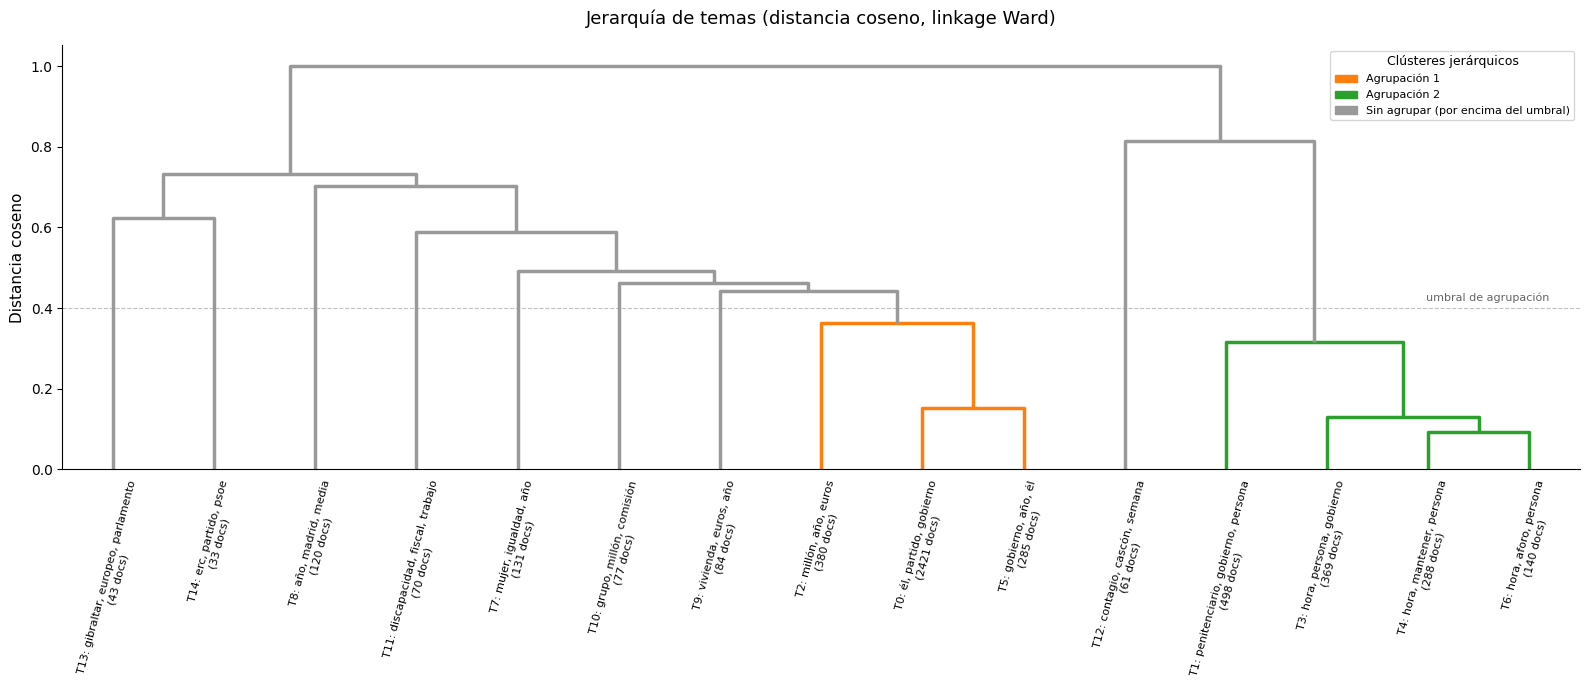

In [12]:
# Jerarquía de temas (construida manualmente para evitar un bug de BERTopic
# con ciertas versiones de plotly/scipy que genera valores negativos en la
# matriz de distancias)
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ctfidf = topic_model.c_tf_idf_.toarray()
if -1 in topic_model.topic_labels_:
    ctfidf = ctfidf[1:]

dist = pdist(ctfidf, metric="cosine")
dist = np.clip(dist, 0, None)
Z = linkage(dist, method="ward")

freq_plot = topic_model.get_topic_freq()
labels = []
for t in sorted(freq_plot[freq_plot.Topic != -1]["Topic"]):
    palabras_top = [w for w, _ in topic_model.get_topic(t)[:3]]
    n_docs = freq_plot.loc[freq_plot.Topic == t, "Count"].values[0]
    labels.append(f"T{t}: {', '.join(palabras_top)}\n({n_docs} docs)")

umbral = 0.4 * max(Z[:, 2])
fig, ax = plt.subplots(figsize=(16, 7))
dendro = dendrogram(
    Z, labels=labels, leaf_rotation=75, leaf_font_size=8,
    ax=ax, color_threshold=umbral, above_threshold_color="#999999",
)
for coll in ax.collections:
    coll.set_linewidth(2.5)
for line in ax.lines:
    line.set_linewidth(2.5)

ax.axhline(y=umbral, color="#999999", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(ax.get_xlim()[1] * 0.98, umbral * 1.03, "umbral de agrupación",
        ha="right", va="bottom", fontsize=8, color="#666666")

colores_ramas = [c for c in set(dendro["color_list"]) if c != "#999999"]
parches = [mpatches.Patch(color=c, label=f"Agrupación {i}") for i, c in enumerate(sorted(colores_ramas), 1)]
parches.append(mpatches.Patch(color="#999999", label="Sin agrupar (por encima del umbral)"))
ax.legend(handles=parches, loc="upper right", fontsize=8,
          title="Clústeres jerárquicos", title_fontsize=9)

ax.set_title("Jerarquía de temas (distancia coseno, linkage Ward)", fontsize=13, pad=15)
ax.set_ylabel("Distancia coseno", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Análisis del dendrograma jerárquico

El dendrograma aporta la información más estructural de las tres visualizaciones, ya que cuantifica las distancias entre temas y revela el orden exacto en que se fusionarían.

Por debajo del umbral de agrupación (línea discontinua al 40% de la distancia máxima) se forman dos clústeres. La **agrupación naranja** une T0 (política nacional y partidos), T5 (gobierno y política económica) y T2 (economía y turismo). T0 y T5 se fusionan a una distancia coseno de apenas ~0.15, la confirmación definitiva de que son esencialmente el mismo tema con distinta granularidad. T2 se incorpora a ~0.36, justo por debajo del umbral: su componente económico (millón, euros, banco) lo acerca al bloque político-económico, aunque su componente turístico (Benidorm, playa) lo diferencia lo suficiente para mantener cierta distancia.

La **agrupación verde** es más reveladora. T4 (restricciones COVID II) y T6 (restricciones COVID III) se fusionan a una distancia de ~0.09, la menor de todo el dendrograma: son el par más similar de los 15 temas. T3 (restricciones COVID I) se une a ellos a ~0.12, completando la triplicación. Pero lo interesante es que T1 (política penitenciaria y País Vasco) se incorpora a este clúster a ~0.32. ¿Por qué un tema sobre transferencias penitenciarias acaba en el mismo grupo que las restricciones COVID? La explicación está en el barchart: T1 arrastra términos como "hora", "mantener", "persona" y "aforo" que le inyectó el `reduce_topics` al fusionar micro-temas. Son precisamente los términos dominantes del clúster COVID, y el dendrograma está detectando esa contaminación léxica.

Los temas grises (por encima del umbral) son los más diferenciados del corpus. T13 (Gibraltar y Parlamento Europeo) y T14 (investidura y pactos parlamentarios) se agrupan entre sí a ~0.62, pero tardan en integrarse al bloque principal (a ~0.73). Lo mismo ocurre con T11 y T8, que se unen como ramas aisladas a ~0.59 y ~0.70 respectivamente. Sin embargo, el tema más aislado semánticamente es T12 (contagio, cascón, semana), que no se une a la rama verde hasta una distancia de ~0.81, forzando la unión final de las dos grandes mitades del corpus a la distancia máxima de 1.0. Hay una correspondencia directa con lo que veíamos en el barchart: los temas con distribución c-TF-IDF más concentrada (donde uno o dos términos dominan claramente) son también los más aislados en el dendrograma. Es lógico: un vocabulario muy específico implica poca superposición léxica con otros temas, y por tanto mayor distancia coseno.

### Reflexión conjunta

Las tres visualizaciones convergen en un mismo diagnóstico. El mapa inter-temas muestra la separación espacial entre los bloques temáticos; el barchart explica esa separación a nivel léxico (distribuciones concentradas vs. planas); y el dendrograma cuantifica las distancias y revela el orden en que los temas se fusionarían.

En conjunto, permiten identificar con precisión los puntos débiles del resultado: la triplicación del tema COVID (T3, T4, T6 a distancia ~0.09-0.12 en el dendrograma, racimo compacto en el mapa, barras idénticas en el barchart) y la contaminación léxica de T1 (penitenciario con residuos de restricciones). También permiten identificar los puntos fuertes: T7 (igualdad/género), T13 (Gibraltar/UE) y T14 (investidura) son temas aislados en el mapa, con distribuciones concentradas en el barchart y distancias altas en el dendrograma, es decir, temas genuinamente diferenciados.

Una última reflexión sobre lo que revelan las visualizaciones acerca de `reduce_topics`: el algoritmo fusiona micro-temas de forma iterativa y greedy, uniendo en cada paso el par con menor distancia c-TF-IDF. Esto explica por qué los tres temas de restricciones COVID sobreviven como temas independientes: en algún momento del proceso iterativo, cada uno estaba más cerca de otro micro-tema (quizá un subtema específico de una comunidad autónoma) que de los otros dos, y las fusiones sucesivas los mantuvieron separados. Si aplicásemos un `reduce_topics` adicional pidiendo 12 temas en lugar de 15, el dendrograma nos dice que T4 y T6 serían los primeros en fusionarse (distancia 0.09), seguidos de T3 (0.12), produciendo un único tema de restricciones COVID con los 797 documentos combinados.

<a id='sec6'></a>
## 6. Análisis del impacto de los hiperparámetros

El número y la calidad de los temas en BERTopic dependen fuertemente de los hiperparámetros de UMAP y HDBSCAN, como se ha visto en el Tema 3. A lo largo de esta práctica hemos experimentado con distintas configuraciones. Recogemos aquí los resultados de forma sistemática, reutilizando los embeddings precalculados para que la comparativa sea eficiente.

In [13]:
configs = {
    "Estándar": {
        "min_cluster_size": 15, "n_neighbors": 15, "n_components": 5,
    },
    "Temas amplios": {
        "min_cluster_size": 40, "n_neighbors": 30, "n_components": 5,
    },
    "Granular (usada)": {
        "min_cluster_size": 8, "n_neighbors": 10, "n_components": 10,
    },
}

resultados_hiper = {}

for nombre, params in configs.items():
    tag = nombre.lower().replace(" ", "_").replace("(", "").replace(")", "")
    modelo_hp_path = os.path.join(SAVE_DIR, f"bertopic_hp_{tag}")

    if os.path.exists(modelo_hp_path):
        modelo_hp = BERTopic.load(modelo_hp_path)
        print(f"{nombre:25s}  (cargado desde disco)")
    else:
        umap_hp = UMAP(
            n_neighbors=params["n_neighbors"],
            n_components=params["n_components"],
            min_dist=0.0, metric="cosine", random_state=42,
        )
        hdbscan_hp = HDBSCAN(
            min_cluster_size=params["min_cluster_size"],
            metric="euclidean", prediction_data=True,
        )
        vectorizer_hp = CountVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.90)
        modelo_hp = BERTopic(
            umap_model=umap_hp, hdbscan_model=hdbscan_hp,
            vectorizer_model=vectorizer_hp,
            language="multilingual", calculate_probabilities=False, verbose=False,
        )
        topics_hp, _ = modelo_hp.fit_transform(docs_lemas.tolist(), embeddings)
        modelo_hp.save(modelo_hp_path, serialization="pickle")

    freq_hp = modelo_hp.get_topic_freq()
    n_temas = len(freq_hp[freq_hp.Topic != -1])
    out_hp = freq_hp.loc[freq_hp.Topic == -1, "Count"]
    pct_out = (out_hp.values[0] / len(docs_original) * 100) if len(out_hp) > 0 else 0
    mayor = freq_hp[freq_hp.Topic != -1].iloc[0]

    resultados_hiper[nombre] = {
        "n_temas": n_temas, "pct_ruido": round(pct_out, 1),
        "tema_mayor_pct": round(mayor["Count"] / len(docs_original) * 100, 1),
        "params": params,
    }
    print(f"{nombre:25s}  |  {n_temas:3d} temas  |  {pct_out:5.1f}% ruido  |  "
          f"Tema mayor: {mayor['Topic']} ({mayor['Count']} docs, {mayor['Count']/len(docs_original)*100:.1f}%)")

print(f"\n{'='*85}")
print(f"{'Configuración':25s} {'min_clust':>10s} {'n_neigh':>8s} {'n_comp':>7s} "
      f"{'Temas':>6s} {'Ruido':>7s} {'Tema mayor':>11s}")
print(f"{'-'*85}")
for nombre, r in resultados_hiper.items():
    p = r["params"]
    print(f"{nombre:25s} {p['min_cluster_size']:>10d} {p['n_neighbors']:>8d} "
          f"{p['n_components']:>7d} {r['n_temas']:>6d} {r['pct_ruido']:>6.1f}% "
          f"{r['tema_mayor_pct']:>10.1f}%")

Estándar                   (cargado desde disco)
Estándar                   |   17 temas  |    0.1% ruido  |  Tema mayor: 0 (4346 docs, 86.9%)
Temas amplios              (cargado desde disco)
Temas amplios              |   10 temas  |    0.0% ruido  |  Tema mayor: 0 (4337 docs, 86.7%)
Granular (usada)           (cargado desde disco)
Granular (usada)           |  119 temas  |   37.7% ruido  |  Tema mayor: 0 (117 docs, 2.3%)

Configuración              min_clust  n_neigh  n_comp  Temas   Ruido  Tema mayor
-------------------------------------------------------------------------------------
Estándar                          15       15       5     17    0.1%       86.9%
Temas amplios                     40       30       5     10    0.0%       86.7%
Granular (usada)                   8       10      10    119   37.7%        2.3%


### Análisis del impacto de los hiperparámetros

La tabla de resultados revela un patrón claro:

La **configuración estándar** (`min_cluster_size=15`) y la de **temas amplios** (`min_cluster_size=40`) producen resultados estructuralmente idénticos: un mega-tema que absorbe el ~87% de los documentos, con apenas 17 y 10 temas respectivamente y prácticamente 0% de ruido. Aumentar `min_cluster_size` de 15 a 40 no resuelve el problema sino que lo agrava: HDBSCAN simplemente exige clústeres más grandes, lo que refuerza el mega-tema dominante en lugar de fragmentarlo.

La **configuración granular** (`min_cluster_size=8`, `n_neighbors=10`, `n_components=10`) produce un resultado radicalmente distinto: 119 temas, 37.6% de ruido y un tema mayor de solo el 2.3%. Aquí intervienen los tres parámetros de forma sinérgica. El `min_cluster_size=8` baja el umbral para considerar un grupo como tema, permitiendo que pequeñas comunidades semánticas se emancipen del macro-clúster. El `n_neighbors=10` (frente al 15 estándar) hace que UMAP preserve más estructura local: micro-vecindarios que con 15 vecinos quedaban diluidos en la masa central ahora mantienen su identidad en el espacio reducido. Y el `n_components=10` (frente a 5) da más grados de libertad para que esas estructuras locales se expresen sin aplastarse en pocas dimensiones.

El porcentaje de ruido del 37.6% merece un comentario. En la teoría de HDBSCAN, el ruido no es un fallo sino una funcionalidad: son documentos que carecen de densidad semántica suficiente para pertenecer a ningún clúster. En nuestro caso, una parte de ese ruido corresponde a documentos genuinamente fronterizos (noticias que mezclan temas), pero otra parte son fragmentos del macro-clúster político que, al aumentar la resolución, no alcanzan la densidad mínima exigida. La reasignación posterior con `reduce_outliers` recupera estos documentos asignándolos al tema cuyo centroide de embeddings está más cercano.

Este análisis ilustra un principio importante de BERTopic: **el modelo no tiene un único "resultado correcto"**. La elección de hiperparámetros determina la resolución temática, de forma análoga a como un microscopio permite observar distintos niveles de detalle según el aumento seleccionado.


<a id='sec7'></a>
## 7. Comparación con modelos clásicos

En la Parte I aplicamos NMF y LDA sobre una DTM de ~58.000 documentos construida con representaciones BoW. Ahora podemos contrastar esos resultados con los obtenidos mediante BERTopic en esta segunda parte.

**Calidad semántica de los temas.** NMF y LDA operan sobre co-ocurrencias léxicas: dos documentos se consideran similares si comparten las mismas palabras. BERTopic, al partir de embeddings contextualizados, puede agrupar documentos que tratan el mismo tema con vocabulario diferente. Sin embargo, la ventaja teórica de los embeddings no se traduce automáticamente en temas más limpios. Con la configuración estándar de HDBSCAN, los temas de BERTopic presentan el mismo problema de fondo que observábamos en NMF con pocos componentes: un bloque político genérico que absorbe la mayoría del corpus. Es con la configuración granular y la posterior fusión cuando BERTopic produce temas comparables en calidad a los de NMF con K=6, aunque con artefactos propios como la triplicación del tema de restricciones COVID.

**Temas compartidos entre ambos enfoques.** Varios temas identificados por BERTopic tienen equivalentes directos en los resultados de NMF de la Parte I. El tema de restricciones COVID (aforo, hostelería, toque de queda) ya aparecía en NMF desde K=4. La política penitenciaria y el País Vasco (ETA, víctimas, audiencia nacional) se consolidó como tema propio en NMF a partir de K=5. El bloque de turismo (Benidorm, playa, hotel) formaba un tema independiente en NMF con K=4, mientras que en BERTopic se ha fusionado con contenido económico. Y el tema sobre Podemos (Iglesias, Espinar, Cañamero), que en NMF aparecía desde K=4, queda aquí absorbido en el tema político genérico (T0). Estas coincidencias no son casuales: reflejan la estructura temática real del corpus, que es independiente del método utilizado.

**Número de temas.** NMF y LDA exigen fijar K a priori, y en la Parte I vimos que los criterios disponibles (inspección manual, similitud coseno media, perplejidad) no convergían: la inspección manual sugería K entre 6 y 8, la similitud coseno señalaba K=5 o K=10, y la perplejidad de LDA descendía de forma monótona sin codo claro. BERTopic delega esta decisión en HDBSCAN, que determina automáticamente el número de clústeres, pero como hemos comprobado en la sección 6, el control fino se desplaza a los hiperparámetros del pipeline. En cierto sentido, la elección de `min_cluster_size` en BERTopic cumple un papel análogo al de K en NMF: determina la granularidad del análisis, aunque de forma indirecta.

**Manejo del ruido.** NMF y LDA asignan todos los documentos a algún tema, incluso los que no encajan bien (asignación soft en LDA, hard en NMF). BERTopic permite que ciertos documentos queden como ruido (tema −1), lo que es más honesto con la realidad de un corpus heterogéneo. Incluso tras aplicar `reduce_outliers`, el modelo identifica explícitamente qué documentos son fronterizos y se han reasignado de forma forzada, una información que NMF y LDA no proporcionan.

**Coste computacional.** El cuaderno completo de la Parte I (preprocesado, vectorización, NMF y LDA con múltiples valores de K) se ejecuta en unos 30-40 minutos sobre los ~58.000 documentos del corpus completo. El cuaderno de esta Parte II tarda aproximadamente 20 minutos sobre una muestra de solo 5000 documentos. Es decir, BERTopic necesita un tiempo comparable para procesar una muestra diez veces menor. La diferencia se debe fundamentalmente a la generación de embeddings con SentenceTransformers (el paso más pesado) y a la reducción de dimensionalidad con UMAP, cuyo coste es muy superior al de la vectorización BoW y la factorización matricial de NMF. Escalar BERTopic al corpus completo de ~58.000 documentos en las mismas condiciones de Colab (CPU, sin GPU) multiplicaría los tiempos de forma considerable, haciendo necesaria la aceleración GPU o la precomputación y almacenamiento de los embeddings, como hemos hecho en esta práctica.

**Sensibilidad a los hiperparámetros.** NMF es relativamente estable: el único parámetro crítico es K. BERTopic tiene una superficie de hiperparámetros más amplia, y como hemos comprobado empíricamente, la diferencia entre una configuración estándar (un mega-tema del 87%) y una granular (119 temas, 37.6% ruido) es drástica. Fijar las semillas aleatorias en UMAP es imprescindible para la reproducibilidad, como se recomienda en las buenas prácticas vistas en clase. En NMF, con `random_state=42` y el mismo K, los resultados son idénticos entre ejecuciones; en BERTopic, la cadena UMAP+HDBSCAN introduce más fuentes de variabilidad.

### Conclusión

La comparación pone de manifiesto que BERTopic y los modelos clásicos no son alternativas que se sustituyan mutuamente, sino herramientas complementarias con perfiles distintos. NMF y LDA son más rápidos, más predecibles y más fáciles de interpretar, lo que los hace adecuados como primera exploración o cuando el corpus es muy grande y los recursos limitados. BERTopic ofrece mayor riqueza semántica y flexibilidad (detección automática de temas, manejo explícito del ruido, embeddings contextualizados), pero a costa de un mayor coste computacional, una mayor sensibilidad a la hiperparametrización y artefactos propios como las fusiones incoherentes que hemos documentado.

Para este corpus concreto, los temas de fondo son los mismos con ambos enfoques (política, COVID, turismo, País Vasco, Podemos), lo que es esperable: la estructura temática es una propiedad del corpus, no del modelo. La diferencia está en cómo cada método la revela. NMF con K=6 producía temas limpios y directamente interpretables. BERTopic requiere un flujo más elaborado (granular + fusión + reasignación) para llegar a un resultado comparable, y aún así presenta artefactos que NMF no tiene. En contrapartida, BERTopic descubre temas específicos como Gibraltar/UE o investidura/pactos que, por su tamaño reducido, quedarían diluidos en NMF a menos que se elevase K por encima de 10, punto donde NMF podría empezar a fragmentarse.

En definitiva, la elección entre un enfoque y otro depende del objetivo del análisis: si se busca una panorámica temática rápida y robusta, NMF o LDA son la opción más eficiente; si se necesita descubrir temas minoritarios o trabajar con corpus multilingües donde las co-ocurrencias léxicas no bastan, BERTopic justifica su mayor complejidad.

<a id='sec8'></a>
## 8. Evaluación cuantitativa de los temas (Opcional)

Para complementar la evaluación cualitativa, calculamos métricas cuantitativas que permiten estimar la calidad de los temas generados, siguiendo las recomendaciones de van der Pol (2025) para la evaluación de modelos BERTopic (https://jpvdp.github.io/NetworkIsLife/Bertopic_metrics.html).

**Diversidad temática.** Mide la redundancia entre temas a través de la proporción de palabras únicas en los top-$n$ términos de todos los temas (excluyendo el tema −1):

$$\text{Diversidad} = \frac{\left|\bigcup_{t=1}^{T} \text{Top}_n(t)\right|}{T \times n} \in [0, 1]$$

Valores altos indican vocabularios diferenciados entre temas; valores bajos revelan solapamiento. No obstante, una diversidad muy alta con temas muy pequeños puede indicar sobre-fragmentación.

**Coherencia temática (NPMI).** Mide la consistencia semántica interna de cada tema evaluando cuánto tienden a co-ocurrir sus palabras representativas dentro de los documentos del corpus. Para cada par de palabras $(w_i, w_j)$ de un tema se calcula la información mutua puntual normalizada:

$$\text{NPMI}(w_i, w_j) = \frac{\log \frac{P(w_i, w_j)}{P(w_i) \cdot P(w_j)}}{-\log\, P(w_i, w_j)}$$

donde $P(w_i)$ es la proporción de documentos que contienen $w_i$ y $P(w_i, w_j)$ la proporción que contiene ambas. El NPMI oscila entre −1 (nunca co-ocurren) y +1 (co-ocurren siempre). La coherencia de un tema es la media de los NPMI de todos los pares de sus top-$n$ palabras, y la coherencia del modelo es la media sobre todos los temas.

Nuestra implementación calcula el NPMI directamente sobre la co-ocurrencia a nivel de documento (presencia/ausencia en la DTM binaria), que es una aproximación a la coherencia UMass. La variante $C_V$, más sofisticada, utiliza vectores NPMI con ventana deslizante y similitud coseno entre ellos, pero requiere dependencias adicionales (como `gensim`) que no incorporamos aquí por simplicidad.

Comparamos el modelo final (granular + fusión) con el intento inicial sobre texto lematizado.

In [14]:
from itertools import combinations

# Diversidad temática
# |Unión de palabras únicas en los top-n de todos los temas| / (T × n)
def calcular_diversidad(tm, topn=10):
    topics = tm.get_topics()
    all_words = []
    for topic_id, words in topics.items():
        if topic_id == -1:  # excluimos el tema de ruido
            continue
        all_words.extend([w for w, _ in words[:topn]])
    if not all_words:
        return 0.0
    # set elimina duplicados: si todas las palabras fuesen únicas,
    # len(set) == len(all_words) y la diversidad sería 1.0
    return len(set(all_words)) / len(all_words)


# Coherencia NPMI
# Para cada tema, calcula la media de NPMI entre todos los pares de sus
# top-n palabras. La coherencia del modelo es la media sobre todos los temas.
def coherencia_npmi(tm, documentos, topn=10):
    # DTM binaria (presencia/ausencia) para calcular co-ocurrencias
    cv = CountVectorizer(binary=True)
    dtm = cv.fit_transform(documentos)
    vocab = cv.get_feature_names_out().tolist()
    n_docs = dtm.shape[0]

    # Frecuencia de documento de cada término: cuántos docs contienen w
    df_vec = np.array(dtm.sum(axis=0)).flatten()
    vocab_to_idx = {w: i for i, w in enumerate(vocab)}

    coherencias = []
    for topic_id, words in tm.get_topics().items():
        if topic_id == -1:
            continue
        # Filtramos palabras que existan en el vocabulario de la DTM
        top_words = [w for w, _ in words[:topn] if w in vocab_to_idx]
        if len(top_words) < 2:
            continue

        npmi_vals = []
        for w1, w2 in combinations(top_words, 2):
            i1, i2 = vocab_to_idx[w1], vocab_to_idx[w2]
            # Co-ocurrencia: nº de documentos donde aparecen ambas palabras
            co = dtm[:, i1].multiply(dtm[:, i2]).sum()
            if co == 0:
                npmi_vals.append(-1.0)  # NPMI mínimo: nunca co-ocurren
                continue
            # Probabilidades estimadas como proporciones sobre el corpus
            p_w1 = df_vec[i1] / n_docs   # P(w1)
            p_w2 = df_vec[i2] / n_docs   # P(w2)
            p_co = co / n_docs            # P(w1, w2)
            # PMI = log(P(w1,w2) / (P(w1)·P(w2))), normalizado por -log(P(w1,w2))
            pmi = np.log(p_co / (p_w1 * p_w2) + 1e-12)
            npmi = pmi / (-np.log(p_co + 1e-12))
            npmi_vals.append(npmi)

        # Coherencia del tema: media de NPMI de todos sus pares
        coherencias.append(np.mean(npmi_vals))

    # Coherencia del modelo: media sobre todos los temas
    return np.mean(coherencias) if coherencias else 0.0


# Cálculo comparativo: modelo final vs. intento con texto lematizado
div_final = calcular_diversidad(topic_model, topn=10)
coh_final = coherencia_npmi(topic_model, docs_lemas.tolist(), topn=10)

div_lemas_v = calcular_diversidad(modelo_lemas, topn=10)
coh_lemas_v = coherencia_npmi(modelo_lemas, docs_lemas.tolist(), topn=10)

print(f"{'Métrica':<30s} {'Modelo final':>14s} {'Intento lematizado':>20s}")
print(f"{'-'*67}")
print(f"{'Diversidad (top-10)':<30s} {div_final:>14.3f} {div_lemas_v:>20.3f}")
print(f"{'Coherencia NPMI (top-10)':<30s} {coh_final:>14.4f} {coh_lemas_v:>20.4f}")

Métrica                          Modelo final   Intento lematizado
-------------------------------------------------------------------
Diversidad (top-10)                     0.627                0.474
Coherencia NPMI (top-10)               0.1846               0.3951


### Interpretación de las métricas

La **diversidad** mejora de 0.474 a 0.627: el modelo final comparte menos vocabulario entre temas que el intento con texto lematizado. Esto confirma cuantitativamente lo que ya observábamos cualitativamente: el intento lematizado tenía temas duplicados con las mismas palabras clave, mientras que el modelo final, al partir de 119 micro-temas fusionados, produce temas con identidad léxica más diferenciada. Una diversidad de 0.627 indica que el 62.7% de las palabras en los top-10 de todos los temas son únicas, un valor razonable aunque no excepcional, precisamente por la triplicación del tema de restricciones COVID que arrastra vocabulario compartido.

La **coherencia NPMI** baja de 0.395 a 0.185, lo que a primera vista podría parecer un retroceso. Sin embargo, esta caída tiene una explicación que la convierte en un resultado esperable más que en un problema. La coherencia NPMI mide co-ocurrencia léxica: cuántas veces las palabras representativas de un tema aparecen juntas en los mismos documentos. El intento lematizado tenía un tema 0 con 4260 documentos (el 85% del corpus) cuyas palabras ("gobierno", "partido", "año", "España") co-ocurren constantemente en cualquier noticia política, inflando artificialmente la métrica. El modelo final, al fragmentar ese mega-tema y distribuir los documentos entre temas más específicos, reduce mecánicamente la co-ocurrencia porque cada tema cubre un subconjunto más restringido del corpus.

Esto ilustra una limitación importante de la coherencia NPMI como métrica: recompensa los temas genéricos con vocabulario de alta frecuencia. Un modelo con un solo tema que contenga todos los documentos tendría una coherencia altísima, pero sería completamente inútil. La diversidad y la inspección manual son complementos imprescindibles para evaluar la calidad real del modelado.

<a id='sec9'></a>
## 9. Declaración de uso responsable de Inteligencia Artificial

En este trabajo se ha utilizado Inteligencia Artificial únicamente como herramienta de apoyo técnico y de mejora de presentación, sin sustituir la autoría académica del contenido.

Usos concretos de la IA durante el desarrollo:
- Asistencia puntual de código para ajustar hiperparámetros y depurar errores.
- Apoyo general en tareas técnicas secundarias.
- Mejora de la redacción y revisión de estilo en los apartados de análisis.
- Revisión de formateo en Markdown.

El planteamiento del trabajo, la estructura, las decisiones metodológicas, el desarrollo experimental, la interpretación de los resultados y las conclusiones comparativas son fruto del trabajo de los autores.